## 10.03 注意力评分函数

### 环境配置

In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import math
    import torch
    from torch import nn
    import torch_npu

warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor")

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

from src.pypto_ops import PyPTOBMM, PyPTOSoftmax, PyPTOTanh, PyPTOLinear
from src.utils import sequence_mask, show_heatmaps

torch.manual_seed(0)


def masked_softmax_torch(X, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return nn.functional.softmax(X.reshape(shape), dim=-1)


def masked_softmax_pypto(X, valid_lens):
    if valid_lens is None:
        return PyPTOSoftmax.apply(X)
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return PyPTOSoftmax.apply(X.reshape(shape))

### 练习 10.3.1

**题目：** 修改小例子中的键，并且可视化注意力权重。可加性注意力和缩放的"点－积"注意力是否仍然产生相同的结果？为什么？

**解答：** 不产生相同的结果。原因：

- **加性注意力**的评分函数 $a(q, k) = w_v^\top \tanh(W_q q + W_k k)$ 含有**可学习参数**（$W_q, W_k, w_v$），能够把不同长度的查询和键投影到同一隐藏空间；
- **缩放点积注意力**的评分函数 $a(q, k) = q^\top k / \sqrt{d}$ 是**固定函数**（无参数），且要求查询与键长度相同。

当所有键完全相同（原例子）时，任意查询与各键的评分一致，两种注意力都得到均匀权重，输出相同；一旦修改键（例如让键彼此不同），两种评分函数给出的注意力权重不再一致，输出也不再相同。

以下使用 `torch` 编程进行验证（把键修改为随机值并对比两种注意力的输出与权重）：

加性注意力输出： tensor([[[ 2.0190,  3.0190,  4.0190,  5.0190]],

        [[ 9.6872, 10.6872, 11.6872, 12.6872]]], grad_fn=<BmmBackward0>)
缩放点积输出： tensor([[[ 2.9681,  3.9681,  4.9681,  5.9681]],

        [[ 8.1798,  9.1798, 10.1798, 11.1798]]])
输出是否相同： False
加性注意力权重最大值： tensor(0.5047, grad_fn=<MaxBackward1>)
缩放点积权重最大值： tensor(0.7420)


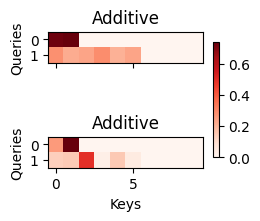

In [2]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class AdditiveAttention(nn.Module):
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super().__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax_torch(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax_torch(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))  # 修改为随机键
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])

add = AdditiveAttention(2, 2, 8, 0.1).eval()
dot = DotProductAttention(0.5).eval()
out_add = add(queries, keys, values, valid_lens)
out_dot = dot(queries, keys, values, valid_lens)
print('加性注意力输出：', out_add)
print('缩放点积输出：', out_dot)
print('输出是否相同：', torch.allclose(out_add, out_dot))
print('加性注意力权重最大值：', add.attention_weights.max())
print('缩放点积权重最大值：', dot.attention_weights.max())
show_heatmaps(torch.cat([add.attention_weights.reshape(1, 1, 2, 10),
                         dot.attention_weights.reshape(1, 1, 2, 10)]),
              xlabel='Keys', ylabel='Queries',
              titles=['Additive', 'Dot-product'])

使用 `PyPTO` 编程进行验证：

PyPTO 加性注意力输出： tensor([[[ 2.0001,  3.0001,  4.0002,  5.0002]],

        [[10.0006, 11.0006, 12.0006, 13.0006]]], device='npu:0',
       grad_fn=<PyPTOBMMImplBackward>)
PyPTO 缩放点积输出： tensor([[[ 2.9681,  3.9681,  4.9681,  5.9681]],

        [[ 8.1798,  9.1798, 10.1798, 11.1798]]], device='npu:0')
输出是否相同： False


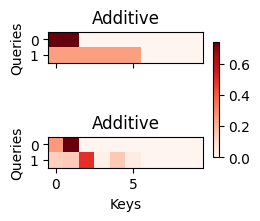

In [3]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class AdditiveAttentionPypto(nn.Module):
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super().__init__(**kwargs)
        self.W_k = PyPTOLinear(key_size, num_hiddens, bias=False)
        self.W_q = PyPTOLinear(query_size, num_hiddens, bias=False)
        self.w_v = PyPTOLinear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = PyPTOTanh.apply(features)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax_pypto(scores, valid_lens)
        return PyPTOBMM.apply(self.dropout(self.attention_weights), values)


class DotProductAttentionPypto(nn.Module):
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = PyPTOBMM.apply(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax_pypto(scores, valid_lens)
        return PyPTOBMM.apply(self.dropout(self.attention_weights), values)


queries_d = queries.to(device)
keys_d = keys.to(device)
values_d = values.to(device)
valid_lens_d = valid_lens.to(device)

add_p = AdditiveAttentionPypto(2, 2, 8, 0.1).to(device).eval()
dot_p = DotProductAttentionPypto(0.5).to(device).eval()
out_add_p = add_p(queries_d, keys_d, values_d, valid_lens_d)
out_dot_p = dot_p(queries_d, keys_d, values_d, valid_lens_d)
print('PyPTO 加性注意力输出：', out_add_p)
print('PyPTO 缩放点积输出：', out_dot_p)
print('输出是否相同：', torch.allclose(out_add_p, out_dot_p))
show_heatmaps(torch.cat([add_p.attention_weights.reshape(1, 1, 2, 10),
                         dot_p.attention_weights.reshape(1, 1, 2, 10)]),
              xlabel='Keys', ylabel='Queries',
              titles=['Additive', 'Dot-product'])

### 练习 10.3.2

**题目：** 只使用矩阵乘法，能否为具有不同矢量长度的查询和键设计新的评分函数？

**解答：** 可以。矩阵乘法要求两个向量的内维一致，因此先分别用投影矩阵把查询与键映射到相同的长度 $h$：

$$a(q, k) = (W_q q)^\top (W_k k) = q^\top W_q^\top W_k k,$$

其中 $W_q \in \mathbb{R}^{h \times q}$、$W_k \in \mathbb{R}^{h \times k}$。当 $q \neq k$ 时 $W_q q$ 与 $W_k k$ 长度均为 $h$，点积合法。这也解释了加性注意力中先做线性投影的必要性。

以下使用 `torch` 编程进行验证：

In [4]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
q, k = torch.randn(20), torch.randn(2)
W_q = torch.randn(8, 20)
W_k = torch.randn(8, 2)
score = (W_q @ q) @ (W_k @ k)   # 纯矩阵乘法
print('不同长度查询/键的矩阵乘法评分：', score.item())

不同长度查询/键的矩阵乘法评分： -10.684717178344727


### 练习 10.3.3

**题目：** 当查询和键具有相同的矢量长度时，矢量求和作为评分函数是否比"点－积"更好？为什么？

**解答：** 求和评分（如先对 $q + k$ 做线性投影得到标量）通常不如点积。原因：点积 $q^\top k$ 度量了两个向量在方向上的**一致性**（夹角余弦，含符号信息），能区分"相似"与"相反"的键；而求和 $q + k$ 只保留分量之和，把方向信息混叠在一起，丢失了查询与键之间的交互结构，表达能力更弱。下面用极端例子验证：键互为相反数时，点积能区分，而求和评分无法区分。

以下使用 `torch` 编程进行验证：

In [5]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
# 两个键互为相反数：点积可区分，求和不可区分
q = torch.tensor([1.0, 0.0])
k1, k2 = torch.tensor([1.0, 0.0]), torch.tensor([-1.0, 0.0])
print('点积评分：', (q @ k1).item(), (q @ k2).item())
W = torch.randn(1, 2)
print('求和评分：', (W @ (q + k1)).item(), (W @ (q + k2)).item())

点积评分： 1.0 -1.0
求和评分： -0.25779131054878235 0.0


---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)